<a href="https://colab.research.google.com/github/kjahan/graph_embeddings/blob/main/notebooks/node2vec_infocom_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INforcome 2006 dataset

Can we use node2vec to model node behavior for social mobile graphs!

## Clone node2vec repo

Let's try this librray that seems to implement te Python 3 versiion of node2vec: https://github.com/eliorc/node2vec

Note that the original source code seems to not working for Python 3. Got the following errors:

!python node2vec/src/main.py --input graph/karate.edgelist --output node2vec/emb/karate.emd

Traceback (most recent call last): File "node2vec/src/main.py", line 15, in <module> import node2vec File "/content/node2vec/src/node2vec.py", line 46 print 'Walk iteration:' ^ SyntaxError: Missing parentheses in call to 'print'. Did you mean print('Walk iteration:')?

https://github.com/aditya-grover/node2vec

https://snap.stanford.edu/node2vec/

In [1]:
!pip install node2vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 11.1 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.2.1
    Uninstalling networkx-3.2.1:
      Successfully uninstalled networkx-3.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lida 0.0.10 requires fastapi, which is not installed.
lida 0.0.10 requires kaleido, which is not installed.
lida 0.0.10 requires python-multipart, which is not installed.
lida 0.0.10 requires uvicorn, which is not installed.


In [81]:
import networkx as nx
from node2vec import Node2Vec

import pandas as pd
import numpy as np

from numpy import dot
from numpy.linalg import norm

## Download Infocom 2006 data

Upload this file:

`Exp6.tar.gz`

In [3]:
!mkdir data

In [9]:
!tar xzvf data/Exp6.tar.gz -C data

Exp6/
Exp6/contacts.Exp6.dat
Exp6/Exp6.README
Exp6/forms/
Exp6/forms/21.dat
Exp6/forms/22.dat
Exp6/forms/23.dat
Exp6/forms/24.dat
Exp6/forms/25.dat
Exp6/forms/26.dat
Exp6/forms/27.dat
Exp6/forms/28.dat
Exp6/forms/29.dat
Exp6/forms/30.dat
Exp6/forms/31.dat
Exp6/forms/32.dat
Exp6/forms/33.dat
Exp6/forms/34.dat
Exp6/forms/35.dat
Exp6/forms/36.dat
Exp6/forms/37.dat
Exp6/forms/38.dat
Exp6/forms/39.dat
Exp6/forms/40.dat
Exp6/forms/41.dat
Exp6/forms/42.dat
Exp6/forms/43.dat
Exp6/forms/44.dat
Exp6/forms/45.dat
Exp6/forms/46.dat
Exp6/forms/47.dat
Exp6/forms/48.dat
Exp6/forms/49.dat
Exp6/forms/50.dat
Exp6/forms/51.dat
Exp6/forms/52.dat
Exp6/forms/53.dat
Exp6/forms/54.dat
Exp6/forms/55.dat
Exp6/forms/56.dat
Exp6/forms/57.dat
Exp6/forms/58.dat
Exp6/forms/59.dat
Exp6/forms/60.dat
Exp6/forms/61.dat
Exp6/forms/62.dat
Exp6/forms/63.dat
Exp6/forms/64.dat
Exp6/forms/65.dat
Exp6/forms/66.dat
Exp6/forms/67.dat
Exp6/forms/68.dat
Exp6/forms/69.dat
Exp6/forms/70.dat
Exp6/forms/71.dat
Exp6/forms/72.dat
Exp6/f

## Load Trace data

=====
`"contacts.Exp6.dat"`

is a file which describes the contact that were recorded by all devices we distributed during this experiment.

`- The first column gives the ID of the device who recorded the sightings. `

`- The second column gives the ID of the device who was seen (it may be an iMote, or another device recorded during the experiment).`

`- The third and fourth column describe, respectively, the first and last time when the address of ID2 were recorded by ID1 for this contact.
Note that the time were computed in seconds, with the zero starting on Sunday at 5:01pm (Please see Origin of time above).`

`- The fifth and sixth column are here for reading convenience. The fifth enumerate contacts with same ID1 and ID2, as 1,2,... . The last column describes the time difference between the beginning of this contact and the end of the previous contact with same ID1 and ID2. It is by convention set to 0 if this is the first contact for this ID1 and ID2.`

`- Note, again, that these contacts may not be mutual between a pair of iMotes, because scanning period of different iMotes are not synchronized, and because the sightings might not be symmetric.`

In [10]:
!head -n 10 data/Exp6/contacts.Exp6.dat

1	3	51293	51293	1	0
1	3	60603	60603	2	9310
1	3	62363	62363	3	1760
1	3	79649	79649	4	17286
1	3	80129	80734	5	480
1	3	80969	80969	6	235
1	3	81330	81330	7	361
1	3	81351	82787	8	21
1	3	83152	83401	9	365
1	3	83644	83644	10	243


## Load Infocome trace data

In [11]:
trace_df = pd.read_csv('data/Exp6/contacts.Exp6.dat', sep="\t", names=["ID1", "ID2", "Start", "End", "Enumerate", "Interval"])

In [12]:
trace_df.shape

(227657, 6)

In [13]:
trace_df.head(5)

,ID1,ID2,Start,End,Enumerate,Interval
0,1,3,51293,51293,1,0
1,1,3,60603,60603,2,9310
2,1,3,62363,62363,3,1760
3,1,3,79649,79649,4,17286
4,1,3,80129,80734,5,480


In [135]:
# Start time is 5pm Sunday - so we check the delta and divide by 3600 to see the hour number
# Let's construc graph for every hour
T = 600 #3600 #second

# 70 students and researchers, attending the student workshop.
# Prune sparse graphs
Min_Edges = 20

In [136]:
def process_trace(df):
  graph_snapshots = {}
  for index, row in df.iterrows():
    id1, id2 = row['ID1'], row['ID2']
    start, end = row['Start'], row['End']
    # Check hour number of this graph based on start time
    hour_no = int(1.0*start/T)
    # sample the graph edge
    edge = id1, id2
    try:
      graph_snapshots[hour_no].append(edge)
    except KeyError:
      graph_snapshots[hour_no] = [edge]
  return graph_snapshots

## Sample edges

In [137]:
Graph_snapshots = process_trace(trace_df)

## Check the snapshots

In [138]:
print(len(Graph_snapshots))

563


In [140]:
list(Graph_snapshots.keys())[:5]

[85, 101, 103, 132, 133]

In [141]:
# Pick snapshots 16 hours after Sunday 5pm
# Every T seconds we are sampling (60 seconds)
# Let's look at the graph on Monday 9am
t1, t2 = 16*6, 16*6+1
G1_edgelist = Graph_snapshots[t1]
G2_edgelist = Graph_snapshots[t2]

G1 = nx.from_edgelist(G1_edgelist, create_using=nx.DiGraph())
G1 = G1.to_undirected()

G2 = nx.from_edgelist(G2_edgelist, create_using=nx.DiGraph())
G2 = G2.to_undirected()

In [142]:
print("G1 no of nodes: {}".format(G1.number_of_nodes()))
print("G2 no of edges: {}\n".format(G1.number_of_edges()))

print("G2 no of nodes: {}".format(G2.number_of_nodes()))
print("G2 no of edges: {}".format(G2.number_of_edges()))

G1 no of nodes: 101
G2 no of edges: 838

G2 no of nodes: 120
G2 no of edges: 833


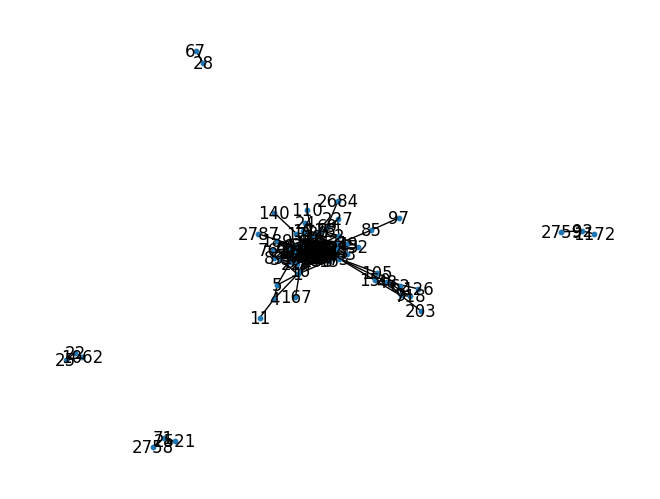

In [162]:
#nx.draw(G1, with_labels = True)

pos = nx.spring_layout(G1)  # or any other layout algorithm
#pos = nx.circular_layout(G1)  # or any other layout algorithm
#nx.draw(G1, pos=pos, with_labels = True)

nx.draw(G1, pos=pos, node_size=10, with_labels = True)


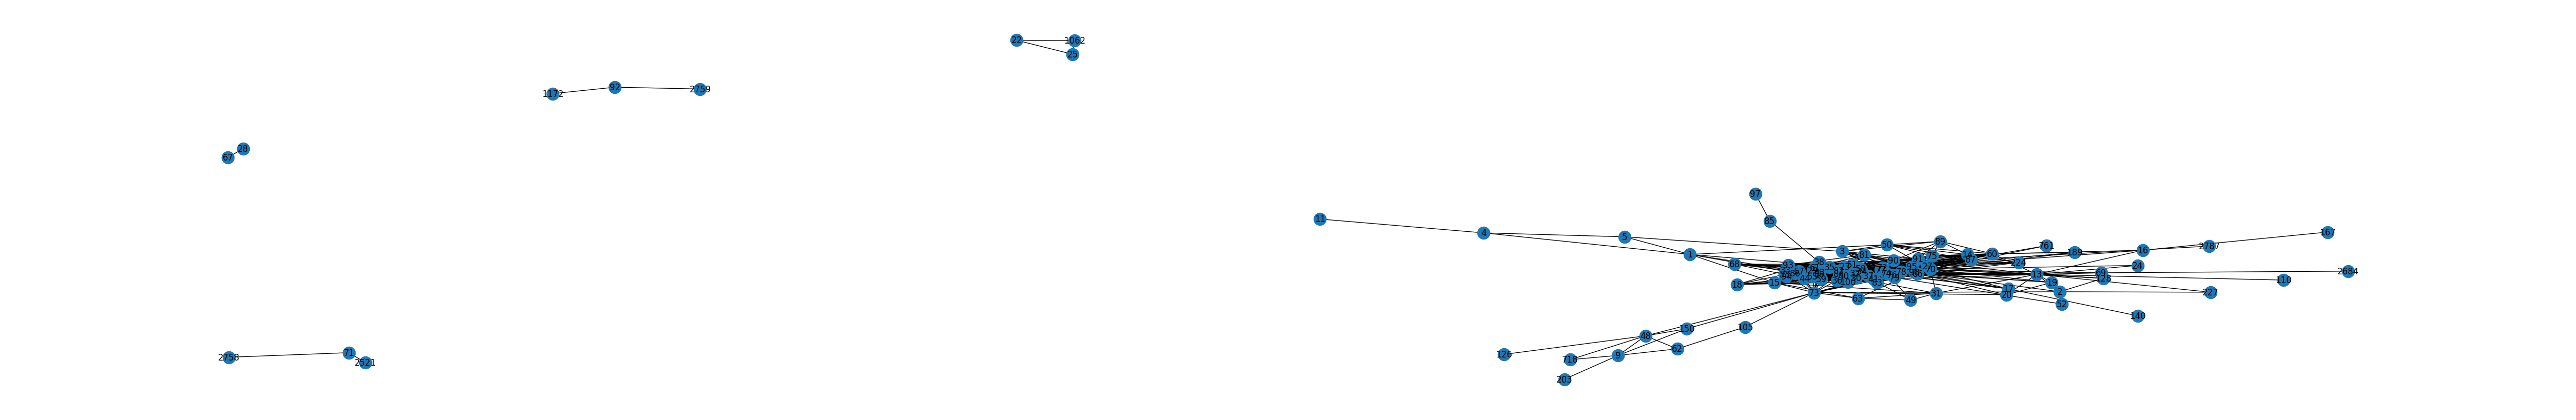

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(50, 8))  # Adjust the size as needed
nx.draw(G1, with_labels = True)
plt.show()

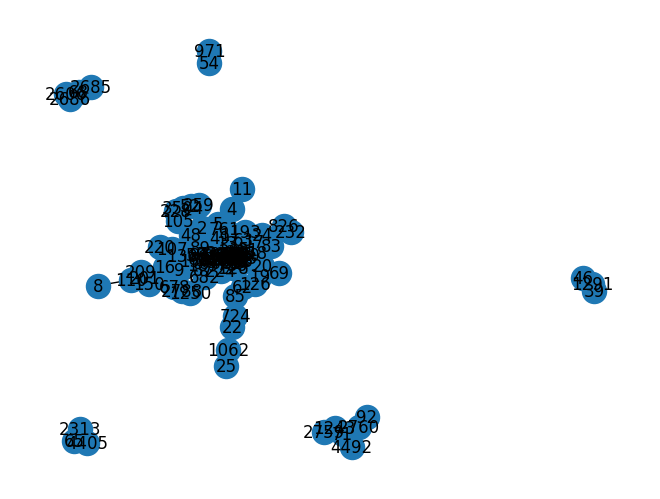

In [144]:
nx.draw(G2, with_labels = True)

## Run Node2Vec for G1

In [145]:
# Precompute probabilities and generate walks - **ON WINDOWS ONLY WORKS WITH workers=1**
node2vec_G1 = Node2Vec(G1, dimensions=50, walk_length=3, num_walks=10, workers=4)  # Use temp_folder for big graphs

# Embed nodes
# Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
model_G1 = node2vec_G1.fit(window=10, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/101 [00:00<?, ?it/s]

In [146]:
n1 = '13'
n2 = '91'

## similar nodes to Node `1`

In [147]:
# Look for most similar nodes
model_G1.wv.most_similar(n1, topn=20)  # Output node names are always strings

[('63', 0.40136393904685974),
 ('52', 0.3451148271560669),
 ('189', 0.3104396462440491),
 ('16', 0.27053046226501465),
 ('32', 0.2512055039405823),
 ('4', 0.22788625955581665),
 ('59', 0.22184036672115326),
 ('66', 0.21792244911193848),
 ('31', 0.2139388918876648),
 ('718', 0.2072123885154724),
 ('40', 0.1993931084871292),
 ('17', 0.19655703008174896),
 ('77', 0.19512172043323517),
 ('28', 0.19162365794181824),
 ('95', 0.17706134915351868),
 ('110', 0.17549428343772888),
 ('87', 0.15586993098258972),
 ('2759', 0.15231674909591675),
 ('73', 0.1500413417816162),
 ('98', 0.149291530251503)]

## Run Node2Vec for G2

In [148]:
# Precompute probabilities and generate walks - **ON WINDOWS ONLY WORKS WITH workers=1**
node2vec_G2 = Node2Vec(G2, dimensions=50, walk_length=3, num_walks=10, workers=4)  # Use temp_folder for big graphs

# Embed nodes
# Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
model_G2 = node2vec_G2.fit(window=10, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/120 [00:00<?, ?it/s]

## similar nodes to Node `1`

In [149]:
model_G2.wv.most_similar(n1, topn=20)  # Output node names are always strings

[('43', 0.38346707820892334),
 ('2760', 0.34443074464797974),
 ('40', 0.32607442140579224),
 ('224', 0.31738317012786865),
 ('36', 0.3039255142211914),
 ('3504', 0.2918475270271301),
 ('71', 0.25333935022354126),
 ('38', 0.24618233740329742),
 ('35', 0.24321535229682922),
 ('2759', 0.22869814932346344),
 ('88', 0.2142992913722992),
 ('1291', 0.20488639175891876),
 ('39', 0.2017287313938141),
 ('55', 0.1985308825969696),
 ('8', 0.19565124809741974),
 ('31', 0.19401885569095612),
 ('61', 0.1933501660823822),
 ('92', 0.1916424185037613),
 ('98', 0.18938355147838593),
 ('9', 0.1859809011220932)]

## Look at a preiphery node

In [150]:
# Look for most similar nodes
model_G1.wv.most_similar(n2, topn=20)  # Output node names are always strings

[('78', 0.3753490149974823),
 ('90', 0.34054458141326904),
 ('17', 0.2602139413356781),
 ('16', 0.25860679149627686),
 ('2758', 0.22458234429359436),
 ('59', 0.2075907438993454),
 ('86', 0.2044580727815628),
 ('30', 0.2013995349407196),
 ('718', 0.18887458741664886),
 ('75', 0.18718315660953522),
 ('11', 0.1842794418334961),
 ('93', 0.18361613154411316),
 ('82', 0.16474448144435883),
 ('58', 0.15123914182186127),
 ('61', 0.13197284936904907),
 ('79', 0.12205632776021957),
 ('23', 0.12195775657892227),
 ('36', 0.11396603286266327),
 ('66', 0.11275260150432587),
 ('140', 0.11232834309339523)]

In [151]:
# Look for most similar nodes
model_G2.wv.most_similar(n2, topn=20)  # Output node names are always strings

[('8', 0.38619861006736755),
 ('38', 0.3665226697921753),
 ('66', 0.3120881915092468),
 ('55', 0.3069337010383606),
 ('2606', 0.2886556088924408),
 ('85', 0.2578739821910858),
 ('201', 0.25672945380210876),
 ('2686', 0.23760151863098145),
 ('93', 0.23551566898822784),
 ('4', 0.23356623947620392),
 ('4492', 0.22394903004169464),
 ('68', 0.22205176949501038),
 ('105', 0.203569233417511),
 ('678', 0.20144419372081757),
 ('95', 0.19428934156894684),
 ('60', 0.18992744386196136),
 ('1', 0.1879323571920395),
 ('20', 0.1877942532300949),
 ('9', 0.17987190186977386),
 ('14', 0.17149247229099274)]

## Get Node2Vec vector from G1 and G2

In [152]:
v1_1 = model_G1.wv[n1]
v2_1 = model_G2.wv[n1]

cos_sim = dot(v1_1, v2_1)/(norm(v1_1)*norm(v2_1))

print(cos_sim)

0.22130455


In [153]:
v1_2 = model_G1.wv[n2]
v2_2 = model_G2.wv[n2]

cos_sim = dot(v1_2, v2_2)/(norm(v1_2)*norm(v2_2))

print(cos_sim)

0.025249789


In [154]:
cos_sim = dot(v1_1, v2_2)/(norm(v1_1)*norm(v2_2))

print(cos_sim)

0.0044614393
